In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

BASE = Path('..').resolve()
REPORTS = BASE / 'reports'
FIGS = REPORTS / 'figures'
TABLES = REPORTS / 'tables'
for p in [FIGS, TABLES]:
    p.mkdir(parents=True, exist_ok=True)

stage_a_candidates = [
    REPORTS / '02_resampling_results.csv',
    REPORTS / 'stage_a_resampling_results.csv'
]
stage_b_candidates = [
    REPORTS / '03_scaling_results.csv',
    REPORTS / 'stage_b_scaling_results.csv'
]
stage_c_candidates = [
    REPORTS / 'model_comparison.csv',
    REPORTS / 'stage_c_model_comparison.csv'
]
summary_candidates = [
    REPORTS / 'final_selection_summary.csv'
]

def pick_existing(candidates, label):
    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        names = ', '.join(p.name for p in candidates)
        raise FileNotFoundError(f'Missing required {label} file. Tried: {names}')
    return path

stage_a_path = pick_existing(stage_a_candidates, 'Stage A report')
stage_b_path = pick_existing(stage_b_candidates, 'Stage B report')
stage_c_path = pick_existing(stage_c_candidates, 'Stage C report')
summary_path = pick_existing(summary_candidates, 'final summary')

stage_a = pd.read_csv(stage_a_path)
stage_b = pd.read_csv(stage_b_path)
stage_c = pd.read_csv(stage_c_path)
summary = pd.read_csv(summary_path)

print('Loaded reports successfully.')
print('Stage A file:', stage_a_path.name, 'shape:', stage_a.shape)
print('Stage B file:', stage_b_path.name, 'shape:', stage_b.shape)
print('Stage C file:', stage_c_path.name, 'shape:', stage_c.shape)


Loaded reports successfully.
Stage A file: 02_resampling_results.csv shape: (4, 7)
Stage B file: 03_scaling_results.csv shape: (6, 8)
Stage C file: model_comparison.csv shape: (5, 7)


## 1. Clean report tables

In [5]:
def save_table_image(df, title, out_path, max_rows=10):
    d = df.head(max_rows).copy()
    fig_h = 1.2 + 0.45 * (len(d) + 1)
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.axis('off')
    table = ax.table(cellText=d.values, colLabels=d.columns, loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.35)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)

stage_a.sort_values(['macro_f1','macro_recall'], ascending=False).to_csv(TABLES / 'table_stage_a.csv', index=False)
stage_b.sort_values(['macro_f1','macro_recall'], ascending=False).to_csv(TABLES / 'table_stage_b.csv', index=False)
stage_c.sort_values(['macro_f1','macro_recall'], ascending=False).to_csv(TABLES / 'table_stage_c.csv', index=False)
summary.to_csv(TABLES / 'table_final_selection.csv', index=False)

save_table_image(stage_a.sort_values(['macro_f1','macro_recall'], ascending=False), 'Stage A - Resampling Results', FIGS / '05_table_stage_a.png')
save_table_image(stage_b.sort_values(['macro_f1','macro_recall'], ascending=False), 'Stage B - Scaling Results', FIGS / '05_table_stage_b.png')
save_table_image(stage_c.sort_values(['macro_f1','macro_recall'], ascending=False), 'Stage C - Final Model Comparison', FIGS / '05_table_stage_c.png')
save_table_image(summary, 'Final Selection Summary', FIGS / '05_table_final_selection.png', max_rows=5)

print('Saved polished tables (CSV + PNG).')


Saved polished tables (CSV + PNG).


## 2. Publication-style charts

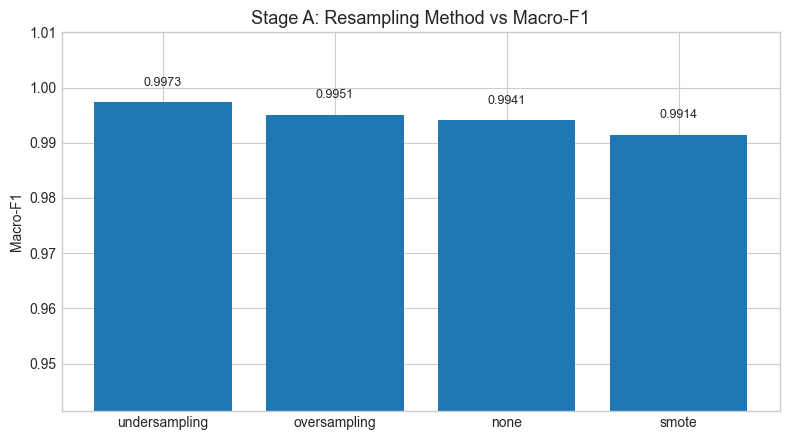

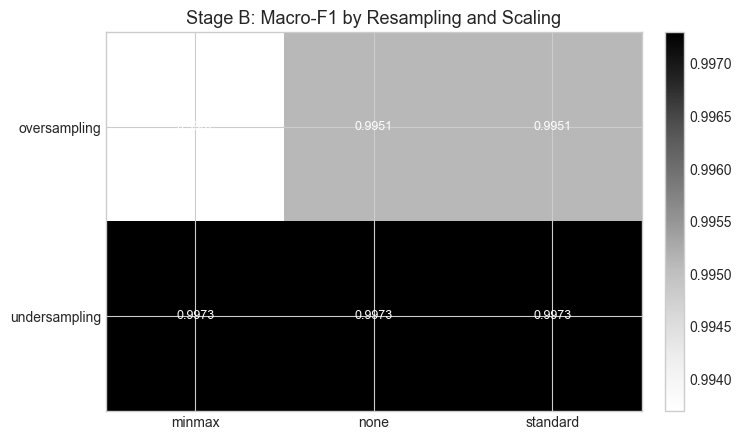

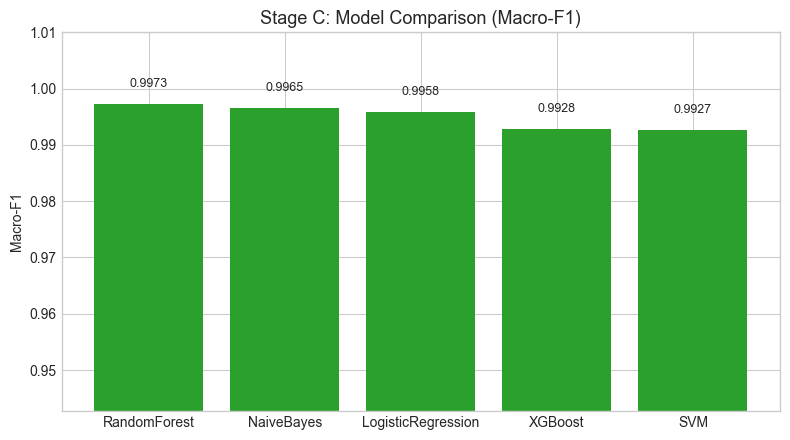

Saved chart set for black-book.


In [6]:
s1 = stage_a.sort_values('macro_f1', ascending=False)
plt.figure(figsize=(8,4.5))
bars = plt.bar(s1['resampling'], s1['macro_f1'], color='#1f77b4')
plt.title('Stage A: Resampling Method vs Macro-F1', fontsize=13)
plt.ylabel('Macro-F1')
plt.ylim(max(0, s1['macro_f1'].min()-0.05), 1.01)
for b in bars:
    h = b.get_height()
    plt.text(b.get_x()+b.get_width()/2, h+0.003, f'{h:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / '05_chart_stage_a_macro_f1.png', dpi=180)
plt.show()

pivot_b = stage_b.pivot(index='resampling', columns='scaling', values='macro_f1')
fig, ax = plt.subplots(figsize=(7.5,4.5))
im = ax.imshow(pivot_b.values, aspect='auto')
ax.set_xticks(range(len(pivot_b.columns)))
ax.set_xticklabels(pivot_b.columns)
ax.set_yticks(range(len(pivot_b.index)))
ax.set_yticklabels(pivot_b.index)
ax.set_title('Stage B: Macro-F1 by Resampling and Scaling', fontsize=13)
for i in range(pivot_b.shape[0]):
    for j in range(pivot_b.shape[1]):
        ax.text(j, i, f"{pivot_b.values[i,j]:.4f}", ha='center', va='center', color='white', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIGS / '05_chart_stage_b_heatmap.png', dpi=180)
plt.show()

s3 = stage_c.sort_values('macro_f1', ascending=False)
plt.figure(figsize=(8,4.5))
bars = plt.bar(s3['model'], s3['macro_f1'], color='#2ca02c')
plt.title('Stage C: Model Comparison (Macro-F1)', fontsize=13)
plt.ylabel('Macro-F1')
plt.ylim(max(0, s3['macro_f1'].min()-0.05), 1.01)
for b in bars:
    h = b.get_height()
    plt.text(b.get_x()+b.get_width()/2, h+0.003, f'{h:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / '05_chart_stage_c_macro_f1.png', dpi=180)
plt.show()

print('Saved chart set for black-book.')


## 3. Executive summary text (copy into report)

In [7]:
best = stage_c.sort_values(['macro_f1','macro_recall'], ascending=False).iloc[0]
res = summary.iloc[0]

summary_text = (
    'Final Experiment Summary\n'
    f"- Top-2 resampling from Stage A: {res['top2_resampling']}\n"
    f"- Best preprocessing combo from Stage B: resampling={res['best_resampling']}, scaling={res['best_scaling']}\n"
    f"- Best model from Stage C: {res['best_model']}\n"
    f"- Best model metrics: Accuracy={best['accuracy']:.4f}, "
    f"Macro Precision={best['macro_precision']:.4f}, "
    f"Macro Recall={best['macro_recall']:.4f}, "
    f"Macro F1={best['macro_f1']:.4f}"
)

print(summary_text)
(REPORTS / 'blackbook_summary.txt').write_text(summary_text, encoding='utf-8')
print('Saved:', REPORTS / 'blackbook_summary.txt')


Final Experiment Summary
- Top-2 resampling from Stage A: undersampling,oversampling
- Best preprocessing combo from Stage B: resampling=undersampling, scaling=none
- Best model from Stage C: RandomForest
- Best model metrics: Accuracy=0.9983, Macro Precision=0.9973, Macro Recall=0.9973, Macro F1=0.9973
Saved: C:\Users\teler\Desktop\api-security-system\new-ml-service\reports\blackbook_summary.txt


## Output files

- `reports/tables/*.csv`
- `reports/figures/05_table_*.png`
- `reports/figures/05_chart_*.png`
- `reports/blackbook_summary.txt`